In [ ]:
!pip install gdown segmentation-models -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input, optimizers, losses, callbacks
from tensorflow.keras.applications import EfficientNetB0, ResNet50, VGG19, MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
from tqdm import tqdm

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

TensorFlow: 2.19.0
Keras: 3.10.0


In [ ]:
print("Verificando GPU...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs encontradas: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No se encontraron GPUs. Usando CPU.")

Verificando GPU...
GPUs encontradas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Descargar datos
!gdown --id 1sHYkAuE-5Z0A1NBFxblvlQ8o8bZZuDyl
!unzip -q Preprocesado_Pix2Pix.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1sHYkAuE-5Z0A1NBFxblvlQ8o8bZZuDyl
From (redirected): https://drive.google.com/uc?id=1sHYkAuE-5Z0A1NBFxblvlQ8o8bZZuDyl&confirm=t&uuid=3c16e9c0-faa9-41b8-b19e-50deab9acbe3
To: /content/Preprocesado_Pix2Pix.zip
100% 1.04G/1.04G [00:14<00:00, 70.4MB/s]


In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
USE_TRANSFER_LEARNING = True
BACKBONE = 'efficientnetb0'
FREEZE_ENCODER_INITIAL = True
UNFREEZE_AT_EPOCH = 20
EPOCHS = 200
BATCH_SIZE = 8
IMG_SIZE = 256
LAMBDA_L1 = 100
LAMBDA_PERCEPTUAL = 10
CHECKPOINT_INTERVAL = 25

PATH = 'Preprocesado_Pix2Pix/'
TRAIN_A_DIR = os.path.join(PATH, 'train_A')
OUTPUT_DIR = 'Resultados_TL_TF'
CHECKPOINT_DIR = '/content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-TL'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\n{'='*70}")
print(f"CONFIGURACIÓN DEL ENTRENAMIENTO")
print(f"{'='*70}")
print(f"Backbone:              {BACKBONE}")
print(f"Transfer Learning:     {USE_TRANSFER_LEARNING}")
print(f"Encoder inicial:       {'Congelado' if FREEZE_ENCODER_INITIAL else 'Entrenable'}")
print(f"Descongelar en época:  {UNFREEZE_AT_EPOCH}")
print(f"Lambda L1:             {LAMBDA_L1}")
print(f"Lambda Perceptual:     {LAMBDA_PERCEPTUAL}")
print(f"Epochs totales:        {EPOCHS}")
print(f"Checkpoints:           {CHECKPOINT_DIR}")
print(f"{'='*70}\n")


CONFIGURACIÓN DEL ENTRENAMIENTO
Backbone:              efficientnetb0
Transfer Learning:     True
Encoder inicial:       Congelado
Descongelar en época:  20
Lambda L1:             100
Lambda Perceptual:     10
Epochs totales:        200
Checkpoints:           /content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-TL



In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = tf.data.Dataset.list_files(TRAIN_A_DIR + '/*.jpg')

def load_and_preprocess(path):
    real_path = tf.strings.regex_replace(path, "train_A", "train_B")

    inp = tf.io.read_file(path)
    inp = tf.image.decode_jpeg(inp, channels=3)
    real = tf.io.read_file(real_path)
    real = tf.image.decode_jpeg(real, channels=3)


    inp = tf.image.resize(inp, [IMG_SIZE, IMG_SIZE])
    real = tf.image.resize(real, [IMG_SIZE, IMG_SIZE])

    if tf.random.uniform(()) > 0.5:
        inp = tf.image.flip_left_right(inp)
        real = tf.image.flip_left_right(real)

    inp = tf.cast(inp, tf.float32) / 127.5 - 1
    real = tf.cast(real, tf.float32) / 127.5 - 1

    return inp, real

train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(1000)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

In [ ]:
def get_generator():
    inputs = Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    if BACKBONE == 'efficientnetb0':
        backbone = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)
        skips = ['block2a_expand_activation', 'block3a_expand_activation',
                 'block4a_expand_activation', 'block6a_expand_activation']
        filters = [512, 256, 128, 64]
    elif BACKBONE == 'resnet50':
        backbone = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
        skips = ['conv1_relu', 'conv2_block3_out', 'conv3_block4_out', 'conv4_block6_out']
        filters = [512, 256, 128, 64]


    backbone.trainable = not FREEZE_ENCODER_INITIAL

    skip_connections = [backbone.get_layer(name).output for name in skips]
    x = backbone.output  # bottleneck

    for f, skip in zip(filters, reversed(skip_connections)):
        x = layers.UpSampling2D()(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        skip = layers.Resizing(x.shape[1], x.shape[2])(skip) if skip.shape[1] != x.shape[1] else skip
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(3, 1, activation='tanh', padding='same')(x)

    model = Model(inputs, x, name='generator')
    return model, backbone

generator, backbone_model = get_generator()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def get_discriminator():
    inp = Input([IMG_SIZE, IMG_SIZE, 3])
    tar = Input([IMG_SIZE, IMG_SIZE, 3])
    x = layers.Concatenate()([inp, tar])

    x = layers.Conv2D(64, 4, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(512, 4, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(1, 4, strides=1, padding='same')(x)

    return Model([inp, tar], x)

discriminator = get_discriminator()

In [ ]:
# Pérdida perceptual (VGG19)
vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False
perceptual_layers = ['block3_conv3', 'block4_conv3']
feature_extractor = Model(vgg.input, [vgg.get_layer(n).output for n in perceptual_layers])

def perceptual_loss(y_true, y_pred):
    y_true = (y_true + 1) / 2
    y_pred = (y_pred + 1) / 2
    a = feature_extractor(y_true)
    b = feature_extractor(y_pred)
    return tf.add_n([tf.reduce_mean(tf.abs(a_i - b_i)) for a_i, b_i in zip(a, b)])

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
def discriminator_loss(real_output, fake_output):
    """
    Pérdida del discriminador con label smoothing (0.9 en vez de 1.0).
    Esto evita que el discriminador sea demasiado confiado y colapse el entrenamiento.
    """
    real_loss = losses.BinaryCrossentropy(from_logits=True)(
        tf.ones_like(real_output) * 0.9,   # Label smoothing: 0.9 en vez de 1.0
        real_output
    )
    fake_loss = losses.BinaryCrossentropy(from_logits=True)(
        tf.zeros_like(fake_output),        # 0.0 para fake
        fake_output
    )
    total_disc_loss = real_loss + fake_loss
    return total_disc_loss

In [ ]:
gen_opt = optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = optimizers.Adam(2e-4, beta_1=0.5)

In [ ]:
ckpt = tf.train.Checkpoint(
    generator=generator,
    discriminator=discriminator,
    gen_opt=gen_opt,
    disc_opt=disc_opt
)
ckpt_manager = tf.train.CheckpointManager(ckpt, CHECKPOINT_DIR, max_to_keep=5)

In [ ]:
@tf.function
def train_step(inp, tar):
    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        fake = generator(inp, training=True)

        real_out = discriminator([inp, tar], training=True)
        fake_out = discriminator([inp, fake], training=True)


        g_loss_gan = losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(fake_out), fake_out)
        g_loss_l1 = tf.reduce_mean(tf.abs(tar - fake))
        g_loss_perc = perceptual_loss(tar, fake)
        g_loss_total = g_loss_gan + LAMBDA_L1 * g_loss_l1 + LAMBDA_PERCEPTUAL * g_loss_perc


        d_loss = discriminator_loss(real_out, fake_out)

    g_grads = g_tape.gradient(g_loss_total, generator.trainable_variables)
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    gen_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    disc_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))


    return (g_loss_total,
            g_loss_gan,
            g_loss_l1,
            g_loss_perc,
            d_loss)

In [ ]:
epoch_g_total_list = []
epoch_g_gan_list   = []
epoch_g_l1_list    = []
epoch_g_perc_list  = []
epoch_d_list       = []
best_gen_loss = np.inf

test_inp, test_tar = next(iter(train_dataset.take(1)))

for epoch in range(EPOCHS):
    start_time = time.time()

    epoch_g_total_list.clear()
    epoch_g_gan_list.clear()
    epoch_g_l1_list.clear()
    epoch_g_perc_list.clear()
    epoch_d_list.clear()


    if USE_TRANSFER_LEARNING and epoch + 1 == UNFREEZE_AT_EPOCH:
        print("\n" + "="*60)
        print("DESCONGELANDO ENCODER PARA FINE-TUNING")
        print("="*60)
        backbone_model.trainable = True
        gen_opt = keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5)
        ckpt.gen_opt = gen_opt

    progbar = tqdm(train_dataset, desc=f"Época {epoch+1}/{EPOCHS}")
    for inp, tar in progbar:
        g_total, g_gan, g_l1, g_perc, d_loss = train_step(inp, tar)

        epoch_g_total_list.append(g_total.numpy())
        epoch_g_gan_list.append(g_gan.numpy())
        epoch_g_l1_list.append(g_l1.numpy())
        epoch_g_perc_list.append(g_perc.numpy())
        epoch_d_list.append(d_loss.numpy())

        progbar.set_postfix({"G": f"{g_total.numpy():.4f}", "D": f"{d_loss.numpy():.4f}"})

    # ========================= RESUMEN DE ÉPOCA =========================
    epoch_time = time.time() - start_time
    print(f"\n{'='*70}")
    print(f"ÉPOCA {epoch+1}/ {EPOCHS} COMPLETADA - Tiempo: {epoch_time:.2f}s ({epoch_time/60:.2f} min)")
    print(f"{'='*70}")
    print(f"Discriminador Loss     → {np.mean(epoch_d_list):.6f}")
    print(f"Generador Total Loss   → {np.mean(epoch_g_total_list):.6f}")
    print(f"   ├─ GAN Loss         → {np.mean(epoch_g_gan_list):.6f}")
    print(f"   ├─ L1 Loss          → {np.mean(epoch_g_l1_list):.6f}")
    print(f"   └─ Perceptual Loss  → {np.mean(epoch_g_perc_list):.6f}")
    print(f"{'='*70}\n")

    current_gen_loss = np.mean(epoch_g_total_list)
    if current_gen_loss < best_gen_loss:
        best_gen_loss = current_gen_loss
        generator.save(f"{CHECKPOINT_DIR}/best_generator.keras")
        print(f"MEJOR MODELO GUARDADO → Loss: {best_gen_loss:.6f}")

    # Imagen de muestra
    pred = generator(test_inp, training=False)
    plt.figure(figsize=(15,5))
    for i, img in enumerate([test_inp[0], test_tar[0], pred[0]]):
        plt.subplot(1,3,i+1)
        plt.imshow(img * 0.5 + 0.5)
        plt.axis('off')
    plt.savefig(f"{OUTPUT_DIR}/epoch_{epoch+1:03d}.jpg", dpi=200, bbox_inches='tight')
    plt.close()

    if (epoch + 1) % CHECKPOINT_INTERVAL == 0 or (epoch + 1) == EPOCHS:
        ckpt_manager.save()
        print(f"Checkpoint guardado en época {epoch+1}")

Época 1/200: 100%|██████████| 245/245 [01:26<00:00,  2.83it/s, G=50.5065, D=0.4159]



ÉPOCA 1/ 200 COMPLETADA - Tiempo: 86.60s (1.44 min)
Discriminador Loss     → 0.646954
Generador Total Loss   → 60.159252
   ├─ GAN Loss         → 2.957700
   ├─ L1 Loss          → 0.286742
   └─ Perceptual Loss  → 2.852734

MEJOR MODELO GUARDADO → Loss: 60.159252


Época 2/200: 100%|██████████| 245/245 [00:47<00:00,  5.15it/s, G=63.1192, D=0.3669]



ÉPOCA 2/ 200 COMPLETADA - Tiempo: 47.62s (0.79 min)
Discriminador Loss     → 0.588570
Generador Total Loss   → 51.429928
   ├─ GAN Loss         → 2.878373
   ├─ L1 Loss          → 0.232719
   └─ Perceptual Loss  → 2.527967

MEJOR MODELO GUARDADO → Loss: 51.429928


Época 3/200: 100%|██████████| 245/245 [00:47<00:00,  5.18it/s, G=43.1923, D=0.5858]


...


ÉPOCA 198/ 200 COMPLETADA - Tiempo: 47.37s (0.79 min)
Discriminador Loss     → 0.325678
Generador Total Loss   → 49.907078
   ├─ GAN Loss         → 10.469913
   ├─ L1 Loss          → 0.177445
   └─ Perceptual Loss  → 2.169264



Época 199/200: 100%|██████████| 245/245 [00:47<00:00,  5.17it/s, G=51.9023, D=0.3257]



ÉPOCA 199/ 200 COMPLETADA - Tiempo: 47.38s (0.79 min)
Discriminador Loss     → 0.325744
Generador Total Loss   → 49.902626
   ├─ GAN Loss         → 10.578896
   ├─ L1 Loss          → 0.177182
   └─ Perceptual Loss  → 2.160553



Época 200/200: 100%|██████████| 245/245 [00:47<00:00,  5.17it/s, G=50.1502, D=0.3259]



ÉPOCA 200/ 200 COMPLETADA - Tiempo: 47.39s (0.79 min)
Discriminador Loss     → 0.325736
Generador Total Loss   → 49.894142
   ├─ GAN Loss         → 10.612665
   ├─ L1 Loss          → 0.177207
   └─ Perceptual Loss  → 2.156082

Checkpoint guardado en época 200


In [ ]:
generator.save(f"{CHECKPOINT_DIR}/generator_final_200ep.keras")
print("Modelo final guardado como .keras")

Modelo final guardado como .keras


In [ ]:
loaded_generator = tf.keras.models.load_model(
    f"{CHECKPOINT_DIR}/generator_final_200ep.keras",
    custom_objects={'perceptual_loss': perceptual_loss}
)
print("Modelo 'generator_final.keras' cargado exitosamente.")

Modelo 'generator_final.keras' cargado exitosamente.


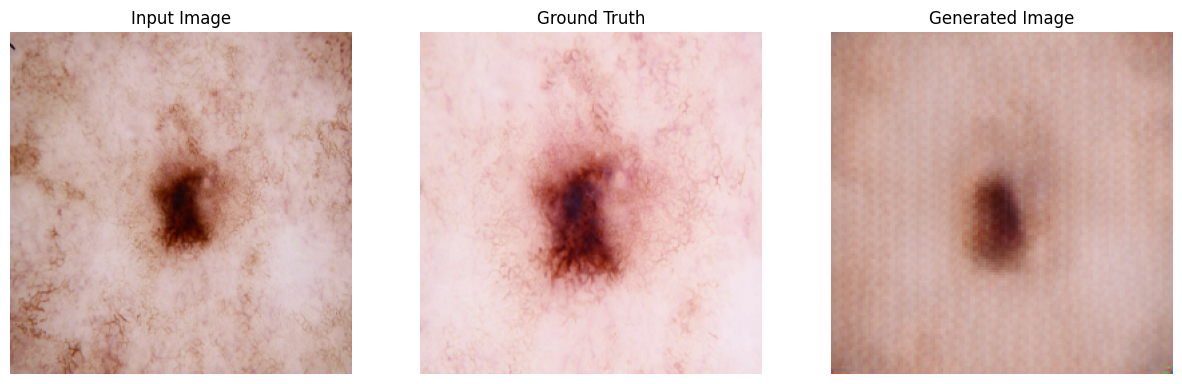

In [ ]:
def predict_and_plot(input_image, real_image, model, num_examples=1):
    prediction = model(input_image, training=False)

    plt.figure(figsize=(15, 5 * num_examples))

    for i in range(num_examples):
        display_list = [input_image[i], real_image[i], prediction[i]]
        title = ['Input Image', 'Ground Truth', 'Generated Image']

        for j in range(3):
            plt.subplot(num_examples, 3, i * 3 + j + 1)
            plt.title(title[j])
            plt.imshow(display_list[j] * 0.5 + 0.5)
            plt.axis('off')
    plt.show()


for inp, tar in train_dataset.take(1):
    predict_and_plot(inp, tar, loaded_generator, num_examples=1)

In [ ]:
#Cargar modelo sin transfer Learning
CHECKPOINT_DIR_sim = '/content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-Simple-1.2'
loaded_generator_base = tf.keras.models.load_model(
    f"{CHECKPOINT_DIR_sim}/generator_final.keras"
)
print("Modelo 'generator_final.keras' cargado exitosamente.")

Modelo 'generator_final.keras' cargado exitosamente.


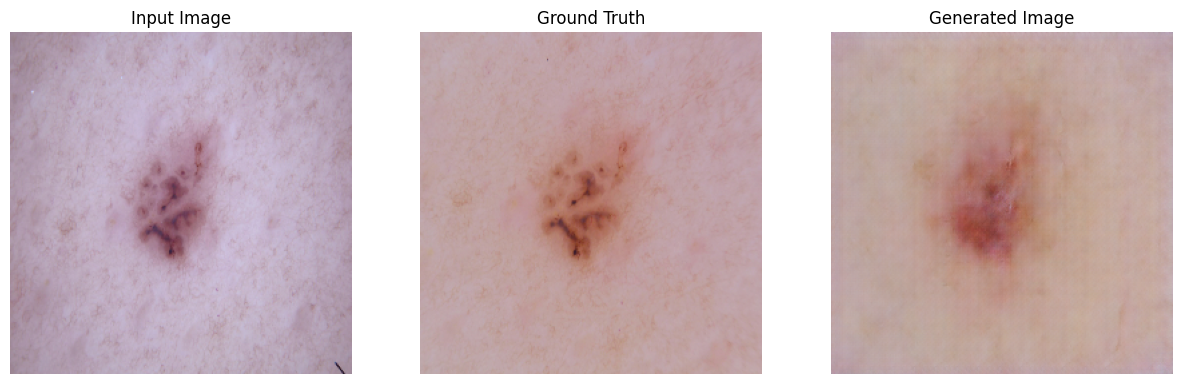

In [ ]:
for inp, tar in train_dataset.take(1):
    predict_and_plot(inp, tar, loaded_generator_base, num_examples=1)